In [4]:
!pip install nilearn scikit-learn matplotlib seaborn pandas -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 56.2 MB/s eta 0:00:00


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import StratifiedKFold, cross_validate

In [6]:
from nilearn import datasets
from nilearn.maskers import NiftiLabelsMasker
from nilearn.connectome import ConnectivityMeasure

In [7]:
adhd = datasets.fetch_adhd(n_subjects=40)

print("Scans:", len(adhd.func))

[fetch_adhd] Added README.md to /root/nilearn_data

[fetch_adhd] Dataset created in /root/nilearn_data/adhd

[fetch_adhd] Downloading data from https://www.nitrc.org/frs/download.php/7781/adhd40_metadata.tgz ...

[fetch_adhd]  ...done. (0 seconds, 0 min)

[fetch_adhd] Extracting data from /root/nilearn_data/adhd/fbef5baff0b388a8c913a08e1d84e059/adhd40_metadata.tgz...

...

[fetch_adhd] Downloading data from https://www.nitrc.org/frs/download.php/7821/adhd40_9750701.tgz ...

[fetch_adhd]  ...done. (1 seconds, 0 min)

[fetch_adhd] Extracting data from /root/nilearn_data/adhd/49718167d83b032094ad6d17e64b4e49/adhd40_9750701.tgz...

[fetch_adhd] .. done.

Scans: 40


In [8]:
labels = adhd.phenotypic["adhd"].values[:len(adhd.func)]

print("Labels:", len(labels))
print(labels[:10])

Labels: 30
[1 0 1 0 1 0 1 0 0 0]


In [9]:
atlas = datasets.fetch_atlas_harvard_oxford(
    "cort-maxprob-thr25-2mm"
)

print("ROIs:", len(atlas.labels))

[fetch_atlas_harvard_oxford] Dataset created in /root/nilearn_data/fsl

[fetch_atlas_harvard_oxford] Downloading data from https://www.nitrc.org/frs/download.php/9902/HarvardOxford.tgz 
...

[fetch_atlas_harvard_oxford]  ...done. (1 seconds, 0 min)

[fetch_atlas_harvard_oxford] Extracting data from 
/root/nilearn_data/fsl/5c734f16e50cc772ef593cab9bb3137b/HarvardOxford.tgz...

[fetch_atlas_harvard_oxford] .. done.

ROIs: 49


In [10]:
masker = NiftiLabelsMasker(
    labels_img=atlas.maps,
    standardize="zscore_sample",
    detrend=True,
    low_pass=0.1,
    high_pass=0.01,
    t_r=2.0
)

In [11]:
corr = ConnectivityMeasure(
    kind="correlation",
    standardize="zscore_sample"
)

In [12]:
X = []
y = []

for func_file, label in zip(adhd.func, labels):
    try:
        ts = masker.fit_transform(func_file)
        mat = corr.fit_transform([ts])[0]
        feat = mat[np.triu_indices_from(mat, k=1)]

        X.append(feat)
        y.append(label)

    except Exception as e:
        print("Skipped:", e)

In [13]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [14]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif, k=50)),
        ("model", LogisticRegression(
            max_iter=5000,
            class_weight="balanced"
        ))
    ]),

    "Linear SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif, k=50)),
        ("model", SVC(
            kernel="linear",
            probability=True,
            class_weight="balanced"
        ))
    ]),

    "Random Forest": Pipeline([
        ("select", SelectKBest(f_classif, k=50)),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ])
}

In [15]:
results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=["accuracy", "roc_auc", "f1"]
    )

    results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "ROC_AUC": scores["test_roc_auc"].mean(),
        "F1": scores["test_f1"].mean()
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,ROC_AUC,F1
0,Logistic Regression,0.366667,0.277778,0.213333
1,Linear SVM,0.433333,0.344444,0.180000
2,Random Forest,0.466667,0.327778,0.326667


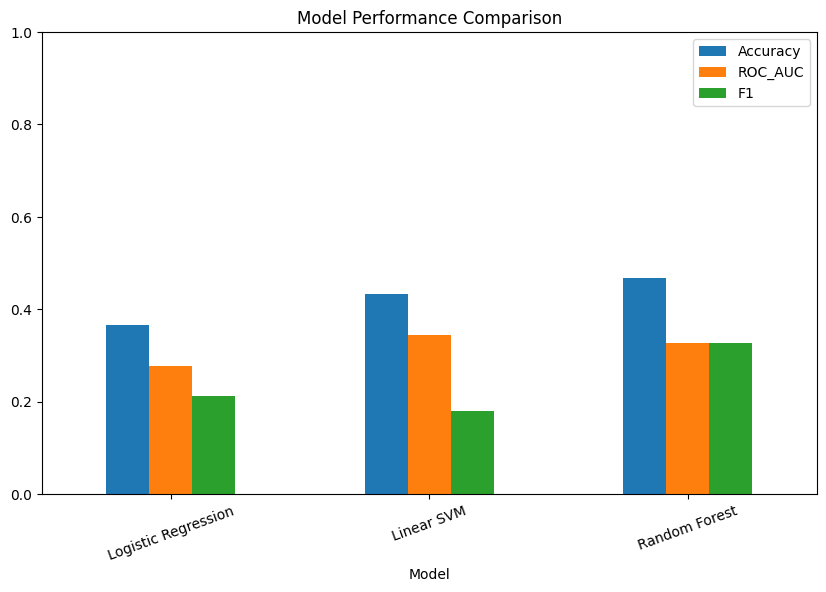

In [16]:
results_df.set_index("Model")[["Accuracy", "ROC_AUC", "F1"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylim(0,1)
plt.xticks(rotation=20)
plt.show()